<a href="https://colab.research.google.com/github/saharkaddour/deep-learning-labs/blob/main/CNN_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Colab setup
If you are running on Google Colab:
- (Recommended) Enable GPU: Runtime → Change runtime type → GPU
- This dataset is built into Keras, so no manual downloads needed.

In [1]:

import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))


2.19.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Imports (do not remove)
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [7]:
# Load CIFAR-10 dataset
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [10]:
# Class names (index -> label)
class_names = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

print("Min pixel:", x_train.min())
print("Max pixel:", x_train.max())


(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)
Min pixel: 0
Max pixel: 255


In [11]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [12]:
from sklearn.model_selection import train_test_split

x_tr, x_val, y_tr, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train.reshape(-1)
)

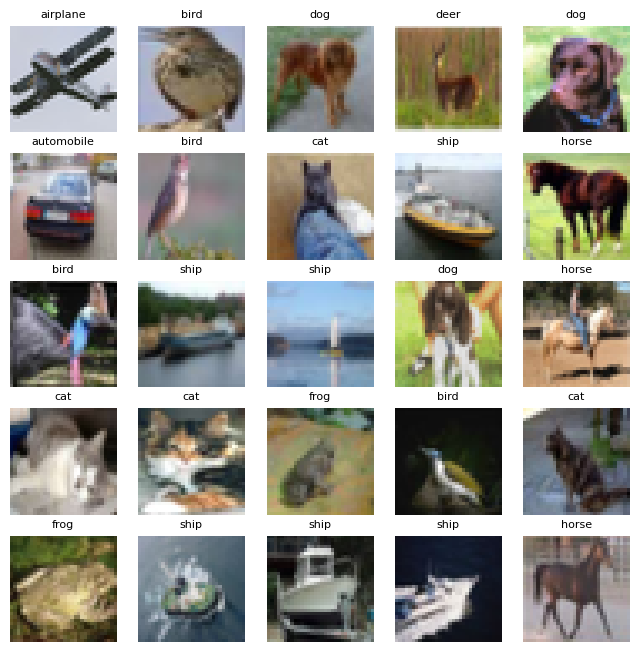

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,8))

indices = np.random.choice(len(x_tr), 25)

for i, idx in enumerate(indices):
    plt.subplot(5,5,i+1)
    plt.imshow(x_tr[idx])
    plt.title(class_names[y_tr[idx][0]], fontsize=8)
    plt.axis("off")

plt.show()

## Part B — Baseline CNN

- Flatten → Dense → Dropout → Dense(softmax)


In [16]:
import tensorflow as tf

model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32,(3,3),activation="relu",input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(64,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(128,(3,3),activation="relu"),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation="relu"),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(10,activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
early = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    x_tr,
    y_tr,
    epochs=20,
    batch_size=64,
    validation_data=(x_val,y_val),
    callbacks=[early]
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.2824 - loss: 1.9097 - val_accuracy: 0.5152 - val_loss: 1.3482
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4978 - loss: 1.3973 - val_accuracy: 0.5617 - val_loss: 1.2366
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5576 - loss: 1.2456 - val_accuracy: 0.6126 - val_loss: 1.1049
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6097 - loss: 1.1116 - val_accuracy: 0.6407 - val_loss: 1.0201
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6502 - loss: 1.0078 - val_accuracy: 0.6787 - val_loss: 0.9258
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6715 - loss: 0.9312 - val_accuracy: 0.6737 - val_loss: 0.9123
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6994 - loss: 0.8613 - val_accuracy: 0.6906 - val_loss: 0.8896
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7186 - loss: 0.8104 - val_accuracy: 0.

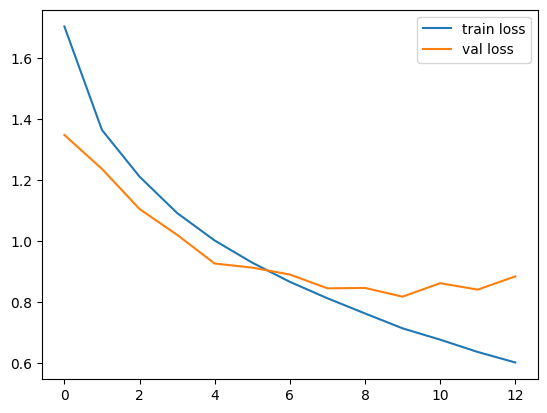

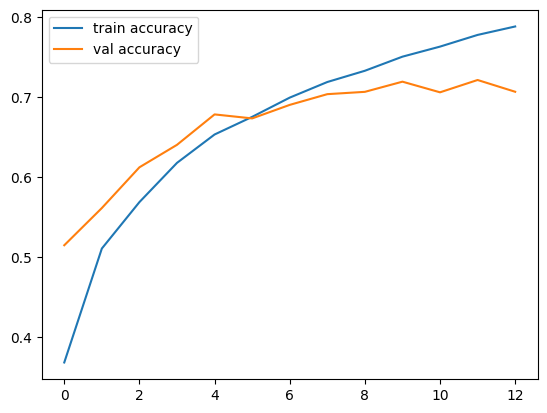

In [20]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")
plt.legend()
plt.show()

## Part C — Evaluation (Test Set)

Now evaluate on the test set (data never seen during training/validation).
Then compute:
- Confusion matrix
- Classification report
- A small gallery of misclassified images

In [21]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)


Test loss: 0.8341878652572632
Test accuracy: 0.7171000242233276


In [23]:
probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(probs, axis=1)
y_true = y_test.reshape(-1)


In [25]:
cm = confusion_matrix(y_true, y_pred)
print(cm)
print(classification_report(y_true, y_pred, target_names=class_names))


[[792  13  44  26  19   2   5   6  68  25]
 [ 24 827   5  12   5   2  14   1  54  56]
 [ 74   2 565  87 128  51  42  32  17   2]
 [ 20   7  72 582  98  99  66  30  15  11]
 [ 25   1  45  56 747  10  49  54  10   3]
 [ 19   2  48 251  63 525  28  54   5   5]
 [  9   6  60  55  54   8 792   5  10   1]
 [ 18   1  30  61  88  41   7 736   8  10]
 [ 66  21   8  13  13   2   3   2 855  17]
 [ 41 100  13  24   8   4   8  16  36 750]]
              precision    recall  f1-score   support

    airplane       0.73      0.79      0.76      1000
  automobile       0.84      0.83      0.84      1000
        bird       0.63      0.56      0.60      1000
         cat       0.50      0.58      0.54      1000
        deer       0.61      0.75      0.67      1000
         dog       0.71      0.53      0.60      1000
        frog       0.78      0.79      0.79      1000
       horse       0.79      0.74      0.76      1000
        ship       0.79      0.85      0.82      1000
       truck       0.85     

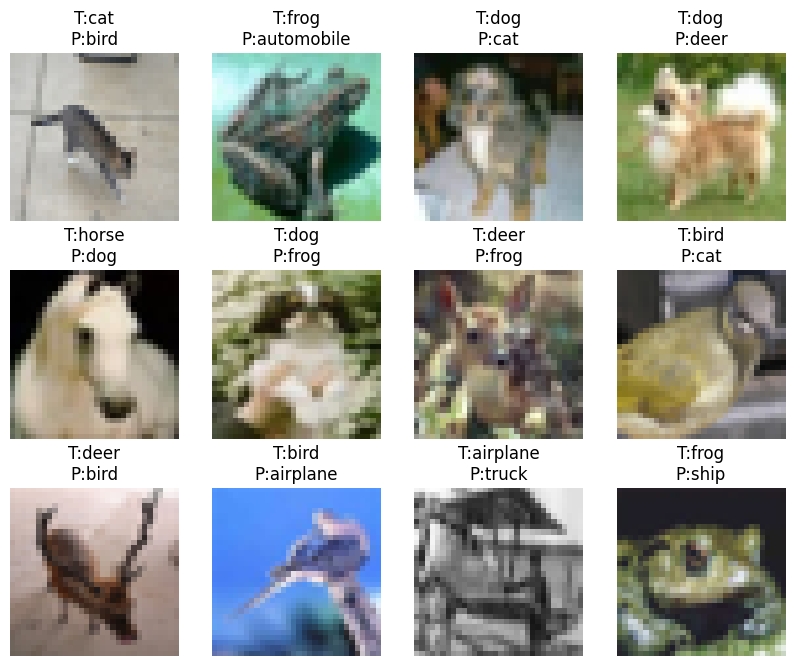

In [26]:
mis_idx = np.where(y_pred != y_true)[0]

samples = np.random.choice(mis_idx, 12)

plt.figure(figsize=(10,8))

for i, idx in enumerate(samples):
    plt.subplot(3,4,i+1)
    plt.imshow(x_test[idx])
    plt.title(f"T:{class_names[y_true[idx]]}\nP:{class_names[y_pred[idx]]}")
    plt.axis("off")

plt.show()

## Part D — Improvement Challenge
Data augmentation (RandomFlip, RandomRotation, RandomTranslation)


In [27]:
data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])
